## Students 

* Ettore Vissa (2197527)
* Enrica Calabretto (2198447)
* Sara Pasquato (2198446)
* Nicolo' Meneguzzo (*******)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting 
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)

#Feed Forward Neural Networks 
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.model_selection import KFold

from sklearn.preprocessing import StandardScaler

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13

XGBoost version: 2.1.4


2026-05-07 14:34:58.552202: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 14:34:58.879000: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-07 14:35:00.223618: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Read and Split the data 

In [2]:
np.random.seed(12345)

dname="./DATA/"
str0="_XGB_26.dat"
fnamex=dname+'x'+str0
fnamey=dname+'y'+str0
x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])

N_train = int(0.75*N)
x_train,y_train = x[:N_train],y[:N_train]
x_val,y_val = x[N_train:],y[N_train:]
print(f"N={N}, N_train={N_train}, L={L}")

N=5000, N_train=3750, L=4


[-31.608 -29.544   6.773   9.554] 0
[46.451 15.318 24.891 15.357] 0
[ 24.771  46.131 -49.161 -39.356] 0
[-20.13   15.641  30.981  37.218] 0
[46.465 22.369 14.248 21.745] 0


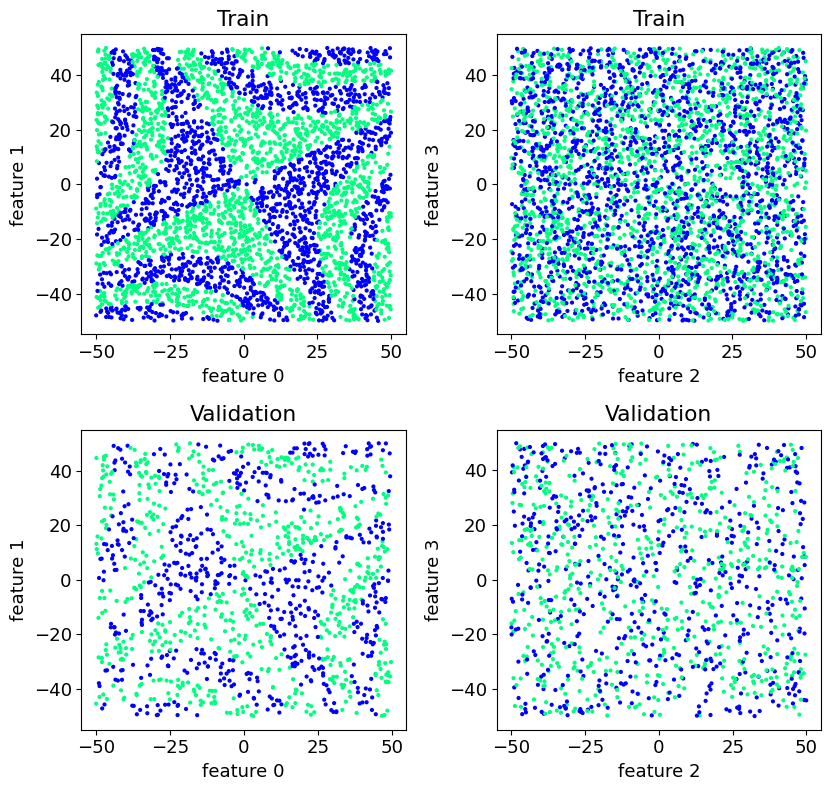

In [3]:
def scat(ax,x,y,i=0,j=1,s=4,title=""):
    # scatter plot of the data in the plane of features i and j
    ax.scatter(x[:,i],x[:,j],s=s,c=y) 
    ax.set_xlabel(f"feature {i}")
    ax.set_ylabel(f"feature {j}")
    ax.set_title(title)

# print the first 5 data points
for n in range(5):
    print(x[n],y[n])

#print feature plots for the training and test sets
fig,AX = plt.subplots(2,2,figsize=(8.5,8.1))
scat(AX[0,0],x_train,y_train,title="Train")
scat(AX[0,1],x_train,y_train,i=2,j=3,title="Train")
scat(AX[1,0],x_val,y_val,title="Validation")
scat(AX[1,1],x_val,y_val,i=2,j=3,title="Validation")
fig.tight_layout()
plt.show()

In [4]:
def classify(clf=GradientBoostingClassifier(),show=False):
    # GradientBoostingClassifier():
    #   n_estimators = 100 (default)
    #   loss function = deviance(default) used in Logistic Regression
    # XGBClassifier()
    #   n_estimators = 100 (default)
    #   max_depth = 3 (default?)
    
    clf.fit(x_train,y_train) # train the model on the training set
    y_hat = clf.predict(x_val) # predict the labels of the test set
    
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_val, y_val)),clf.score(x_val, y_val)))
    S=50 # size of the square grid
    dx = 1
    x_seq=np.arange(-S,S+dx,dx) # sequence of points for the grid
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L)) # grid of points
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] # only the first two features are used for the artificial grid
            q+=1
    y_plot= clf.predict(x_plot) # predict the labels of the grid points

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()
    
    if show:      
        dump_list = clf.get_booster().get_dump() # get the list of trees in the model
        num_trees = len(dump_list)
        print("num_trees=",num_trees)
        
        fig, AX = plt.subplots(2,1,figsize=(12, 5))
        for i in range(min(2,num_trees)):
            ax=AX[i]
            plot_tree(clf, num_trees=i, ax=ax)
        fig.savefig("DATA/tree-classif.png", dpi=400, pad_inches=0.02)   
        plt.show()

## 1. Model complexity, parameters and regularization

## 2. Dimensionality reduction

## 3. XGBoost vs NN

In [7]:
sizes = [5000, 4000, 3000, 2000, 1000, 500]

np.random.seed(12345)
base_idx = np.random.permutation(5000)
combinations_list = [base_idx[:s] for s in sizes]

x0 = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y0 = np.loadtxt(fnamey)

acc_xgb_single = []
acc_nn_single = []

acc_xgboost = []
acc_ffnn = []

for comb in combinations_list:
    x = x0[comb,:] 
    y = y0[comb].astype(int)
    N,L = len(x), len(x[0])

    N_train = int(0.75*N)
    x_train,y_train = x[:N_train],y[:N_train]
    x_val,y_val = x[N_train:],y[N_train:]
    
    # XGBoost SINGLE 
    model_boost = XGBClassifier(
        seed=1,
        objective='binary:logistic',
        n_estimators=100,
        max_depth=3
    )
    
    model_boost.fit(x_train, y_train)
    acc_xgb0=model_boost.score(x_val, y_val)
    acc_xgb_single.append(acc_xgb0) 

    
    # FFNN SINGLE
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    
    model_ffnn = Sequential([
        Dense(32, activation='relu', input_shape=(L,)),
        Dense(16, activation='relu'),
        Dropout(0.1),
        Dense(8, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])

    model_ffnn.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model_ffnn.fit(x_train, y_train,epochs=200,batch_size=16,verbose=0)
    loss, acc_nn0 = model_ffnn.evaluate(x_val, y_val, verbose=0)
    acc_nn_single.append(acc_nn0)


    # KFOLD
    kf = KFold(n_splits=5, shuffle=True, random_state=1)

    # XGBoost KFold    
    acc_list_xgb = []
    for train_index, val_index in kf.split(x):
        x_tr, x_vl = x[train_index], x[val_index]
        y_tr, y_vl = y[train_index], y[val_index]

        model_boost = XGBClassifier(
            seed=1,
            objective='binary:logistic',
            n_estimators=100,
            max_depth=3
        )

        model_boost.fit(x_tr, y_tr)
        acc_list_xgb.append(model_boost.score(x_vl, y_vl))

    acc_xgb = np.mean(acc_list_xgb)
    acc_xgboost.append(acc_xgb)
    
    
    # FFNN KFold 
    acc_list_nn = []
    for train_index, val_index in kf.split(x):
        x_tr, x_vl = x[train_index], x[val_index]
        y_tr, y_vl = y[train_index], y[val_index]

        scaler = StandardScaler()
        x_tr = scaler.fit_transform(x_tr)
        x_vl = scaler.transform(x_vl)
        
        model_ffnn = Sequential([
            Dense(32, activation='relu', input_shape=(L,)),
            Dense(16, activation='relu'),
            Dropout(0.1),
            Dense(8, activation='relu'),
            Dropout(0.1),
            Dense(1, activation='sigmoid')
        ])

        model_ffnn.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        model_ffnn.fit(x_tr, y_tr, epochs=200, batch_size=16, verbose=0)
        loss, acc = model_ffnn.evaluate(x_vl, y_vl, verbose=0)
        acc_list_nn.append(acc)

    acc_nn = np.mean(acc_list_nn)
    acc_ffnn.append(acc_nn)
    
    print(f'           MODEL OF SIZE {x.shape} \n ')
    print("\n Results before K-FOLD ")
    print(f"XGBoost single Accuracy: {acc_xgb0:.3f}")
    print(f"FFNN    single Accuracy: {acc_nn0:.3f}")
    print("\n Results after K-FOLD ")
    print(f"XGBoost KFold Accuracy: {acc_xgb:.3f}")
    print(f"FFNN    KFold Accuracy: {acc_nn:.3f} \n \n \n ")

           MODEL OF SIZE (5000, 4) 
 


/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_reg


 Results before K-FOLD 
XGBoost single Accuracy: 0.873
FFNN    single Accuracy: 0.916

 Results after K-FOLD 
XGBoost KFold Accuracy: 0.848
FFNN    KFold Accuracy: 0.868 
 
 
 
           MODEL OF SIZE (4000, 4) 
 


/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_reg


 Results before K-FOLD 
XGBoost single Accuracy: 0.818
FFNN    single Accuracy: 0.806

 Results after K-FOLD 
XGBoost KFold Accuracy: 0.854
FFNN    KFold Accuracy: 0.831 
 
 
 
           MODEL OF SIZE (3000, 4) 
 


...


 Results before K-FOLD 
XGBoost single Accuracy: 0.802
FFNN    single Accuracy: 0.566

 Results after K-FOLD 
XGBoost KFold Accuracy: 0.803
FFNN    KFold Accuracy: 0.607 
 
 
 
           MODEL OF SIZE (1000, 4) 
 


/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_reg


 Results before K-FOLD 
XGBoost single Accuracy: 0.724
FFNN    single Accuracy: 0.560

 Results after K-FOLD 
XGBoost KFold Accuracy: 0.741
FFNN    KFold Accuracy: 0.543 
 
 
 
           MODEL OF SIZE (500, 4) 
 


/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_reg


 Results before K-FOLD 
XGBoost single Accuracy: 0.600
FFNN    single Accuracy: 0.568

 Results after K-FOLD 
XGBoost KFold Accuracy: 0.636
FFNN    KFold Accuracy: 0.480 
 
 
 


In the comparison between XGBoost and a feed-forward neural network (FFNN) on the generated dataset, XGBoost clearly outperforms the neural network both when reducing the training set size and when using all 5000 samples. This behavior is mainly due to the nature of the data: the target function is a step-like nonlinear function that depends only on the first two features, which is ideally suited for tree-based models like XGBoost. The neural network, while flexible, tends to produce smooth continuous approximations and suffers from underfitting even on the full dataset, especially with a small number of layers and neurons.


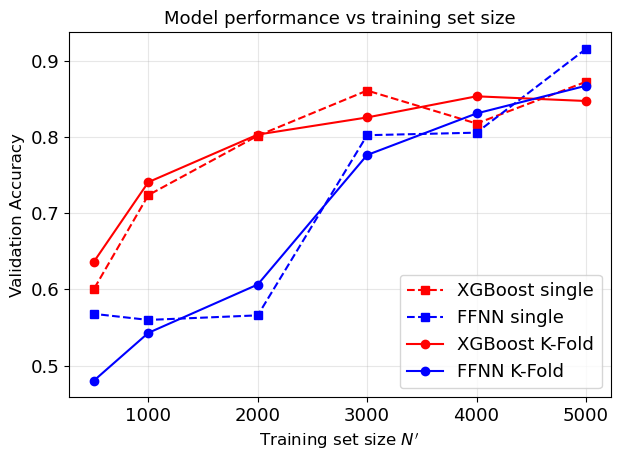

In [8]:
n= [5000, 4000, 3000, 2000, 1000, 500]

plt.plot(n, acc_xgb_single, marker='s', linestyle='--', color='red', label='XGBoost single')
plt.plot(n, acc_nn_single, marker='s', linestyle='--', color='blue', label='FFNN single')
plt.plot(n, acc_xgboost, marker='o', linestyle='-', color='red', label='XGBoost K-Fold')
plt.plot(n, acc_ffnn, marker='o', linestyle='-', color='blue', label='FFNN K-Fold')

plt.legend()
plt.xlabel('Training set size $N\'$', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Model performance vs training set size', fontsize=13)
plt.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("accuracy_vs_N.png", dpi=300)
plt.show()

It’s clear that XGBoost performs reasonably well even with small sample sizes *n*, while the neural network shows very low accuracy. It may even appear to improve as *n* decreases, but this is misleading—in reality, it is behaving almost randomly, since the sample sizes are far too small to train the model reliably.

/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


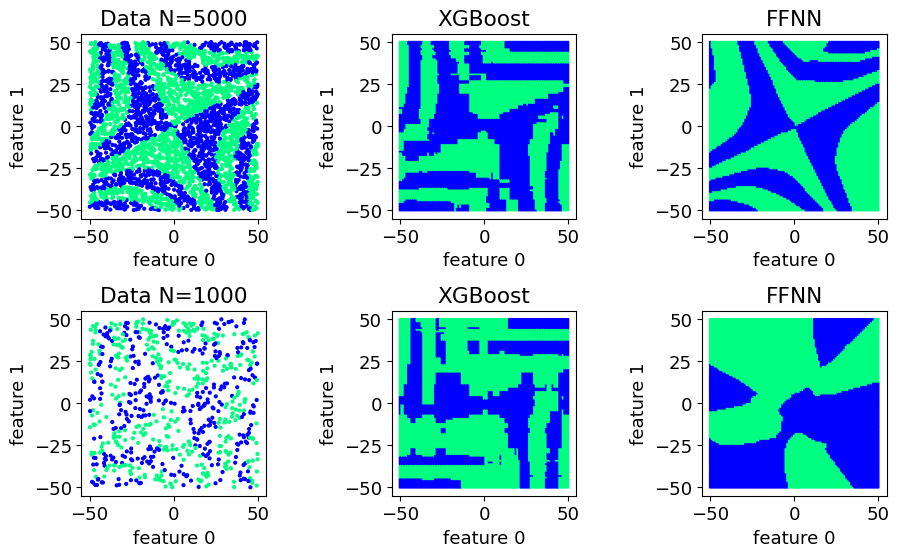

In [11]:
selected_sizes = [5000, 1000]
sizes = [5000, 4000, 3000, 2000, 1000, 500]

np.random.seed(12345)
base_idx = np.random.permutation(5000)
combinations_dict = {s: base_idx[:s] for s in sizes}

x0 = np.loadtxt(fnamex, delimiter=" ", dtype=float)
y0 = np.loadtxt(fnamey)

fig, AX = plt.subplots(len(selected_sizes),3,figsize=(12, 3*len(selected_sizes)))

if len(selected_sizes) == 1:
    AX = np.array([AX])

# LOOP ONLY ON SELECTED SIZES
for row, Nsel in enumerate(selected_sizes):

    comb = combinations_dict[Nsel]

        # DATASET
    x = x0[comb, :]
    y = y0[comb].astype(int)

    N, L = x.shape
    N_train = int(0.75 * N)

    x_train, y_train = x[:N_train], y[:N_train]
    x_val, y_val = x[N_train:], y[N_train:]

    # XGBOOST
    model_xgb = XGBClassifier(seed=1,
        objective='binary:logistic',
        n_estimators=100,
        max_depth=3)

    model_xgb.fit(x_train, y_train)

    acc_xgb = model_xgb.score(x_val, y_val)

    # FFNN
    scaler = StandardScaler()

    x_train_nn = scaler.fit_transform(x_train)
    x_val_nn = scaler.transform(x_val)

    model_ffnn = Sequential([
        Dense(32, activation='relu', input_shape=(L,)),
        Dense(16, activation='relu'),
        Dropout(0.1),
        Dense(8, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')])

    model_ffnn.compile(optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy'])

    model_ffnn.fit(x_train_nn,y_train,epochs=200,batch_size=16,verbose=0)
    loss, acc_ffnn = model_ffnn.evaluate(x_val_nn,y_val,verbose=0)

    
    # GRID
    S = 50
    dx = 1

    x_seq = np.arange(-S, S + dx, dx)
    nx = len(x_seq)

    x_plot = np.zeros((nx * nx, L))

    q = 0
    for i in range(nx):
        for j in range(nx):
            x_plot[q, :2] = [x_seq[i], x_seq[j]]
            q += 1

    # PREDICTIONS
    y_plot_xgb = model_xgb.predict(x_plot)

    x_plot_nn = scaler.transform(x_plot)
    y_plot_ffnn = model_ffnn.predict(x_plot_nn, verbose=0)
    y_plot_ffnn = (y_plot_ffnn > 0.5).astype(int)

    # PLOTS
    scat(AX[row, 0],x_train,y_train,title=f"Data N={N}")
    scat(AX[row, 1],x_plot,y_plot_xgb,s=dx,title=f"XGBoost")
    scat(AX[row, 2],x_plot,y_plot_ffnn,s=dx,title=f"FFNN")
    
    AX[row, 0].set_box_aspect(1)
    AX[row, 1].set_box_aspect(1)
    AX[row, 2].set_box_aspect(1)

plt.subplots_adjust(wspace=0.002, hspace=0.5)
#plt.savefig("data_XGB_NN.png", dpi=300)
plt.show()